In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

# Загрузка данных

In [17]:
import os
from typing import List
from datetime import datetime

from dotenv import load_dotenv
import pandas as pd

from fractal.loaders.thegraph.uniswap_v3 import EthereumUniswapV3Loader
from fractal.loaders.base_loader import LoaderType
from fractal.core.base import Observation
from examples.tau_strategy.tau_strategy import build_observations
from fractal.loaders.thegraph.uniswap_v3.uniswap_v3_pool import UniswapV3EthereumPoolHourDataLoader, UniswapV3EthereumPoolMinuteDataLoader
from fractal.loaders.binance import BinanceHourPriceLoader, BinanceMinutePriceLoader
from fractal.loaders.structs import PoolHistory, PriceHistory
from fractal.core.entities.uniswap_v3_lp import UniswapV3LPGlobalState



def get_observations(
        pool_data: PoolHistory, price_data: PriceHistory,
        start_time: datetime = None, end_time: datetime = None
    ) -> List[Observation]:
    """
    Get observations from the pool and price data for the TauResetStrategy.

    Returns:
        List[Observation]: The observation list for TauResetStrategy.
    """
    observations_df: pd.DataFrame = pool_data.join(price_data)
    observations_df = observations_df.dropna()
    # observations_df = observations_df.loc[start_time:end_time]
    if start_time is None:
        start_time = observations_df.index.min()
    if end_time is None:
        end_time = observations_df.index.max()
    observations_df = observations_df[observations_df.tvl > 0]
    observations_df = observations_df.sort_index()
    print(f"observations_df.columns {observations_df.columns}")
    return [
        Observation(
            timestamp=timestamp,
            states={
                'UNISWAP_V3': UniswapV3LPGlobalState(
                    price=price, 
                    tvl=tvls, 
                    volume=volume, 
                    fees=fees, 
                    liquidity=liquidity,
                    centralized_price=centralized_price,
                    open_price=open,
                    close_price=close,
                    high_price=high,
                    low_price=low,
                ),
            }
        ) for timestamp, (tvls, volume, fees, liquidity, price, open, high, low, close, centralized_price) in observations_df.iterrows()
    ]


def build_observations(
        ticker: str, pool_address: str, api_key: str,
        start_time: datetime = None, end_time: datetime = None, fidelity: str = 'hour',
    ) -> List[Observation]:
    """
    Build observations for the TauResetStrategy from the given start and end time.
    """
    if fidelity == 'hour':
        pool_data: PoolHistory = UniswapV3EthereumPoolHourDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV, start_time=start_time, end_time=end_time).read(with_run=True)
        binance_prices: PriceHistory = BinanceHourPriceLoader(ticker, loader_type=LoaderType.CSV).read(with_run=True)
        print(f"pool_data.columns {pool_data.columns}")
    elif fidelity == 'minute':
        pool_data: PoolHistory = UniswapV3EthereumPoolMinuteDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV).read(with_run=True)
        binance_prices: PriceHistory = BinanceMinutePriceLoader(ticker, loader_type=LoaderType.CSV,
                                                                start_time=start_time, end_time=end_time).read(with_run=True)

        
    return get_observations(pool_data, binance_prices, start_time, end_time)



load_dotenv()
ticker: str = 'ETHUSDT'
pool_address: str = '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8'
THE_GRAPH_API_KEY = os.getenv('THE_GRAPH_API_KEY')

# Load data
token0_decimals, token1_decimals = EthereumUniswapV3Loader(
    THE_GRAPH_API_KEY, loader_type=LoaderType.CSV).get_pool_decimals(pool_address)

# Build observations
observations: List[Observation] = build_observations(
    ticker=ticker, 
    pool_address=pool_address,
    api_key=THE_GRAPH_API_KEY,
    start_time=datetime(2024, 3, 20), # min timestamp with fees > 0
    # start_time=datetime(2021, 1, 1), # min timestamp with fees > 0
    end_time=datetime(2025, 4, 25),
    fidelity='hour'
)
observation0 = observations[0]
observation0


current_loaded_time: 2024-04-30 17:00:00
current_loaded_time: 2024-06-12 02:00:00
current_loaded_time: 2024-07-24 08:00:00
current_loaded_time: 2024-09-04 07:00:00
current_loaded_time: 2024-10-17 15:00:00
current_loaded_time: 2024-11-29 00:00:00
current_loaded_time: 2025-01-10 03:00:00
current_loaded_time: 2025-02-20 22:00:00
current_loaded_time: 2025-04-03 13:00:00
current_loaded_time: 2025-04-26 05:00:00
pool_data.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'token0_price', 'open', 'high',
       'low', 'close'],
      dtype='object')
observations_df.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'token0_price', 'open', 'high',
       'low', 'close', 'price'],
      dtype='object')


Observation(timestamp=2024-03-19 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=317256101.3949567, volume=536895.7831671502, fees=1610.6873495014509, liquidity=1.4513494727019018e+18, price=3285.5963803529758, centralized_price=3293.01, open_price=3279.179804687722, close_price=3285.5963803529758, high_price=3287.09640069871, low_price=3264.396181006303)})

In [18]:
token0_decimals, token1_decimals

(6.0, 18.0)

# Разделение на train\test

In [19]:
from typing import Tuple


def split_observations_by_time(
    observations: List[Observation],
    train_ratio: float = 0.8,
    test_ratio: float = 0.2
) -> Tuple[List[Observation], List[Observation]]:
    """
    Split observations into train and test sets by timestamp.
    The split is done chronologically to maintain the time sequence.
    
    Args:
        observations: List of observations to split
        train_ratio: Ratio of observations to use for training (default: 0.7)
        test_ratio: Ratio of observations to use for testing (default: 0.3)
        
    Returns:
        Tuple of (train_observations, test_observations)
        
    Raises:
        ValueError: If train_ratio + test_ratio != 1.0
    """
    if not (0 < train_ratio < 1 and 0 < test_ratio < 1):
        raise ValueError("train_ratio and test_ratio must be between 0 and 1")
    
    if abs(train_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("train_ratio + test_ratio must equal 1.0")
    
    # Sort observations by timestamp to ensure chronological order
    sorted_observations = sorted(observations, key=lambda x: x.timestamp)
    
    # Calculate split indices
    total_obs = len(sorted_observations)
    train_size = int(total_obs * train_ratio)
    
    # Split observations
    train_observations = sorted_observations[:train_size]
    test_observations = sorted_observations[train_size:]
    
    return train_observations, test_observations
    


In [20]:
train_observations, test_observations = split_observations_by_time(observations)

In [21]:
len(train_observations)

7634

In [22]:
print(min([obs.timestamp for obs in train_observations]))
print(min([obs.timestamp for obs in test_observations]))


2024-03-19 21:00:00+00:00
2025-02-05 17:00:00+00:00


# Обучение

In [8]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
# %env CLEARML_API_ACCESS_KEY=<Your access key>
# %env CLEARML_API_SECRET_KEY=<Your secret key>

%env CLEARML_API_ACCESS_KEY=75J86NR0W672MX1IMXSAW3Z74PKA4C
%env CLEARML_API_SECRET_KEY=1tnDAKa-O0bMYJPx89g5XuubsM3WoJr0vjH9z5DdLj4bwYhaF7uyx2To47WzLQWoSS4

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=75J86NR0W672MX1IMXSAW3Z74PKA4C
env: CLEARML_API_SECRET_KEY=1tnDAKa-O0bMYJPx89g5XuubsM3WoJr0vjH9z5DdLj4bwYhaF7uyx2To47WzLQWoSS4


In [148]:
from fractal.strategies.rl_strategy import RLStrategy, RLStrategyParams


from clearml import Task

task = Task.init(
    project_name='AI_IN_BLOCKCHAIN', 
    task_name='UNISWAP_V3_LP_RL_STRATEGY',
    auto_resource_monitoring=False,
)

params = RLStrategyParams(
    INITIAL_BALANCE=10 ** 5,
    LEARNING_RATE=0.0003,
    N_STEPS=1024,
    BATCH_SIZE=64,
    N_EPOCHS=2 * int(1e2),
    GAMMA=0.99,
    GAE_LAMBDA=0.95,
    CLIP_RANGE=0.2,
    SEED=42,
    FEES_RATE=10,
    ALPHA=0.9,
    BETA=2000.0,
    NU_LR=1e-2,
    LAM_LR=1e-2,
    NU_START=0.0,
    LAM_START=0.5,
    NU_DELAY=0.8,
    MAX_CONSTRAINT_VALUE=1000,
    MAX_BACKTRACK_STEPS=10,
    BACKTRACK_COEFF=0.8,
    DAMPING_COEFF=0.1,
    CONSTRAINT_LR=1e-2,
    MAX_IMPERMANENT_LOSS=200,
    IMPERMANENT_LOSS_QUANTILE=0.95,
)
print(params)
RLStrategy.token0_decimals = token0_decimals
RLStrategy.token1_decimals = token1_decimals
RLStrategy.tick_spacing = 60

strategy = RLStrategy(params, debug=True)

print("Training...")
# Run the strategy on a sequence of observations
result = strategy.train(train_observations, total_timesteps=int(1.5 * 1e5))

task.close()

ClearML Task: created new task id=c0ed2d3407b448f4bda5d1e2a3add2d3
======> WARNING! Git diff too large to store (1249kb), skipping uncommitted changes <======
ClearML results page: https://app.clear.ml/projects/ec648bc989a74c32b4a58e89c2a5e095/experiments/c0ed2d3407b448f4bda5d1e2a3add2d3/output/log
RLStrategyParams(INITIAL_BALANCE=100000, LEARNING_RATE=0.0003, N_STEPS=1024, BATCH_SIZE=64, N_EPOCHS=200, GAMMA=0.99, GAE_LAMBDA=0.95, CLIP_RANGE=0.2, SEED=42, FEES_RATE=10, ALPHA=0.9, BETA=2000.0, NU_LR=0.01, LAM_LR=0.01, NU_START=0.0, LAM_START=0.5, NU_DELAY=0.8, LAM_LOW_BOUND=0.001, DELAY=1.0, CVAR_CLIP_RATIO=0.05, MAX_CONSTRAINT_VALUE=1000, MAX_BACKTRACK_STEPS=10, BACKTRACK_COEFF=0.8, DAMPING_COEFF=0.1, CONSTRAINT_LR=0.01, MAX_IMPERMANENT_LOSS=200, IMPERMANENT_LOSS_QUANTILE=0.95)
Training...


In [113]:
# task.close()

In [149]:
strategy._remove_entity("UNISWAP_V3")
strategy.set_up()
strategy.deposited_initial_funds = False
result = strategy.run(test_observations)

In [150]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from fractal.core.base.strategy.result import StrategyResult
from typing import Optional
    

def visualize_results(strategy_result: StrategyResult, save_path: Optional[str] = None):
    """
    Visualize the strategy results including price movement and liquidity boundaries.
    
    Args:
        strategy_result: The result from running the strategy
        save_path: Optional path to save the plot
    """
    # Convert timestamps to datetime objects
    timestamps = np.array([pd.to_datetime(ts) for ts in strategy_result.timestamps])
    
    # Extract data
    prices = np.array([state['UNISWAP_V3'].price for state in strategy_result.global_states])
    lower_bounds = np.array([state['UNISWAP_V3'].price_lower for state in strategy_result.internal_states])
    upper_bounds = np.array([state['UNISWAP_V3'].price_upper for state in strategy_result.internal_states])
    
    # Create figure with subplots
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    
    # Plot price and boundaries
    ax.plot(timestamps, prices, label='Price', color='blue', linewidth=1)
    # ax.plot(timestamps, lower_bounds, label='Lower Bound', color='red', linewidth=1)
    # ax.plot(timestamps, upper_bounds, label='Upper Bound', color='green', linewidth=1)
    ax.scatter(timestamps[lower_bounds > 0], lower_bounds[lower_bounds > 0], label='Lower Bound', color='red', marker='o', s=5)
    ax.scatter(timestamps[upper_bounds > 0], upper_bounds[upper_bounds > 0], label='Upper Bound', color='green', marker='o', s=5)

    plt.vlines(x=timestamps[lower_bounds > 0], ymin=lower_bounds[lower_bounds > 0], ymax=upper_bounds[lower_bounds > 0], colors='green', lw=0.1)

    
    # Fill between boundaries
    # ax.fill_between(timestamps, lower_bounds, upper_bounds, color='gray', alpha=0.2)
    
    # Format price plot
    ax.set_ylabel('Price')
    ax.set_title('Price Movement and Liquidity Boundaries')
    ax.legend()
    ax.grid(True)
    
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save or show plot
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
    
    plt.close()

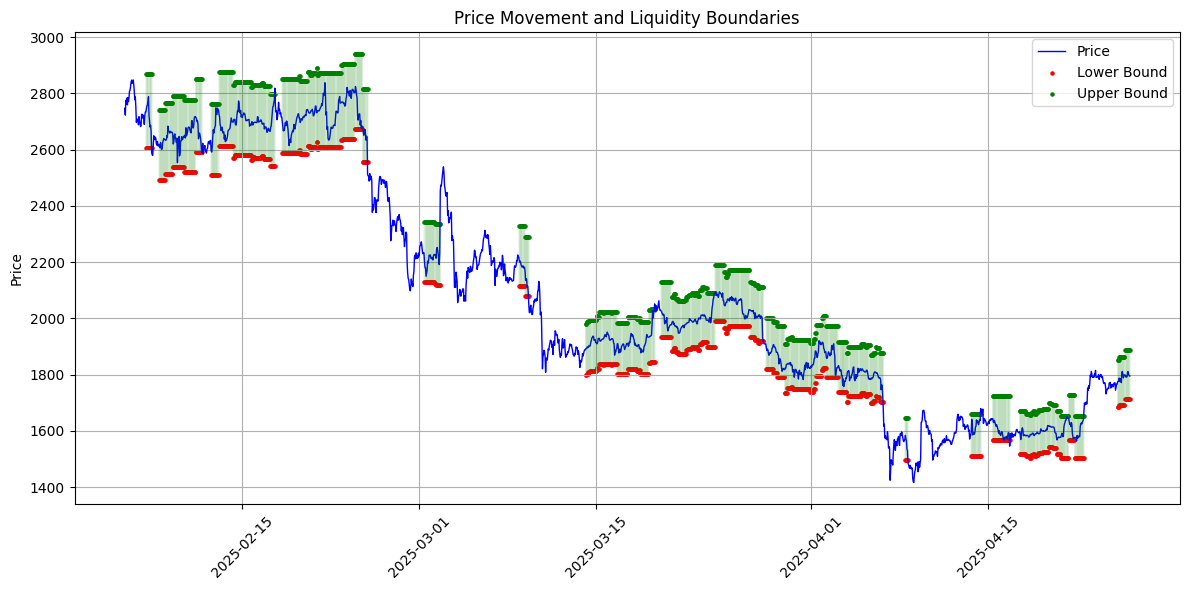

In [151]:
visualize_results(result)

In [152]:
result.get_default_metrics()

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:65: RuntimeWarning:

divide by zero encountered in scalar divide

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:80: RuntimeWarning:

invalid value encountered in divide



StrategyMetrics(accumulated_return=np.float64(inf), apy=np.float64(inf), sharpe=np.float64(nan), max_drawdown=np.float64(nan))

In [153]:
df = result.to_dataframe()
df

,timestamp,UNISWAP_V3_token0_amount_hold,UNISWAP_V3_token1_amount_hold,UNISWAP_V3_token0_amount_position,UNISWAP_V3_token1_amount_position,UNISWAP_V3_token0_amount_position_init,UNISWAP_V3_token1_amount_position_init,UNISWAP_V3_price_init,UNISWAP_V3_price_lower,UNISWAP_V3_price_upper,...,UNISWAP_V3_volume,UNISWAP_V3_fees,UNISWAP_V3_price,UNISWAP_V3_centralized_price,UNISWAP_V3_open_price,UNISWAP_V3_close_price,UNISWAP_V3_high_price,UNISWAP_V3_low_price,UNISWAP_V3_balance,net_balance
0,2025-02-05 17:00:00+00:00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.477178e+06,4431.532861,2747.014106,2739.19,2774.773563,2747.014106,2774.876184,2740.555787,0.000000,0.000000
1,2025-02-05 18:00:00+00:00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.791593e+06,5374.779436,2722.849678,2721.73,2746.290695,2722.849678,2746.504657,2722.849678,100000.000000,100000.000000
2,2025-02-05 19:00:00+00:00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.904431e+06,5713.293263,2775.723994,2774.50,2722.849678,2775.723994,2775.738665,2722.848394,100000.000000,100000.000000
3,2025-02-05 20:00:00+00:00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.131565e+06,3394.694368,2762.104139,2761.54,2775.732682,2762.104139,2775.732682,2752.825588,100000.000000,100000.000000
4,2025-02-05 21:00:00+00:00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.395634e+05,2218.690333,2783.549796,2785.85,2762.690264,2783.549796,2783.549796,2762.690264,100000.000000,100000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904,2025-04-26 01:00:00+00:00,0.0,0.0,46058.476902,19.207991,40325.019803,22.385317,1798.423116,1714.072976,1886.772309,...,1.174263e+06,3522.788870,1810.580614,1806.39,1794.621981,1810.580614,1811.070762,1794.621981,80907.413359,80907.413359
1905,2025-04-26 02:00:00+00:00,0.0,0.0,46113.543494,19.177579,40325.019803,22.385317,1798.423116,1714.072976,1886.772309,...,3.964127e+05,1189.238097,1810.697578,1807.14,1810.500327,1810.697578,1810.697578,1808.191390,80916.545055,80916.545055
1906,2025-04-26 03:00:00+00:00,0.0,0.0,40977.267043,22.022779,40325.019803,22.385317,1798.423116,1714.072976,1886.772309,...,8.492736e+05,2547.820921,1799.804108,1796.51,1810.133091,1799.804108,1810.133091,1799.804108,80716.370908,80716.370908
1907,2025-04-26 04:00:00+00:00,0.0,0.0,39543.254188,22.820212,40325.019803,22.385317,1798.423116,1714.072976,1886.772309,...,1.497269e+05,449.180767,1796.768595,1790.91,1799.804108,1796.768595,1799.804108,1796.768580,80652.578861,80652.578861


In [154]:
df[(df["UNISWAP_V3_price_upper"] > 0) & (df["UNISWAP_V3_price_lower"] > 0)].groupby(["UNISWAP_V3_price_upper", "UNISWAP_V3_price_lower"]).nth(0)["UNISWAP_V3_earned_fees"]

41      13.312739
65      12.367800
77       6.556708
91       7.044655
113     12.666298
          ...    
1804     0.000995
1806     0.009890
1885    12.925291
1888    30.587958
1899     6.616259
Name: UNISWAP_V3_earned_fees, Length: 143, dtype: float64

In [155]:
df["UNISWAP_V3_earned_fees"].unique().sum()

np.float64(218126.23214554315)

# Metrics Calculation

In [158]:
def calculate_total_return_and_apy(df):
    """Calculate total return and APY from strategy results"""
    initial_balance = df['net_balance'].iloc[1]
    final_balance = df['net_balance'].iloc[-1]
    total_return = (final_balance / initial_balance - 1) if initial_balance != 0 else 0
    
    # Calculate days between first and last timestamp
    days = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).days
    apy = ((1 + total_return) ** (365/days) - 1) if days > 0 else 0
    
    return total_return, apy

def calculate_fees_to_tvl_ratio(df):
    """Calculate ratio of earned fees to locked capital (TVL)"""
    position_df = df[(df["UNISWAP_V3_price_upper"] > 0) & (df["UNISWAP_V3_price_lower"] > 0)]
    
    position_df = (
        position_df
        .groupby(["UNISWAP_V3_price_upper", "UNISWAP_V3_price_lower"])
        .nth(-1)
    )
    # Calculate impermanent loss for each position
    ratio_values = []
    for _, row in position_df.iterrows():
        current_fees = row['UNISWAP_V3_earned_fees']
        initial_balance = row['net_balance']
        
        if initial_balance > 0:
            # Calculate price ratio
            price_ratio = current_fees / initial_balance
            
            ratio_values.append(abs(price_ratio))
    
    return np.mean(ratio_values) if ratio_values else 0

def calculate_impermanent_loss_mean(df):
    """Calculate mean impermanent loss"""
    # Filter rows where position exists
    position_df = df[(df["UNISWAP_V3_price_upper"] > 0) & (df["UNISWAP_V3_price_lower"] > 0)]

    position_df = (
        position_df
        .groupby(["UNISWAP_V3_price_upper", "UNISWAP_V3_price_lower"])
        .nth(-1)
    )
    
    # Calculate impermanent loss for each position
    il_values = []
    for _, row in position_df.iterrows():
        current_price = row['UNISWAP_V3_price']
        initial_price = row['UNISWAP_V3_price_init']
        
        if initial_price > 0:
            # Calculate price ratio
            price_ratio = current_price / initial_price
            
            # Calculate impermanent loss using the formula: IL = 2√(P2/P1)/(1 + P2/P1) - 1
            il = 2 * np.sqrt(price_ratio) / (1 + price_ratio) - 1
            il_values.append(abs(il))
    
    return np.mean(il_values) if il_values else 0

def calculate_returns_volatility(df):
    """Calculate returns volatility"""
    # Calculate daily returns
    returns = df['net_balance'].pct_change().dropna()
    # Calculate annualized volatility
    annual_volatility = returns.std() * np.sqrt(365)
    return annual_volatility

def calculate_max_drawdown(df):
    """Calculate maximum drawdown"""
    # Calculate cumulative maximum of net balance
    rolling_max = df['net_balance'].expanding().max()
    # Calculate drawdown
    drawdown = df['net_balance'] / rolling_max - 1
    # Get maximum drawdown
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_liquidity_interval_width(df):
    """Calculate mean width of liquidity interval"""
    # Calculate width between upper and lower bounds
    upper_bounds = np.floor(df[df['UNISWAP_V3_price_upper'] > 0]['UNISWAP_V3_price_upper'] / 60) * 60
    lower_bounds = np.floor(df[df['UNISWAP_V3_price_lower'] > 0]['UNISWAP_V3_price_lower'] / 60) * 60
    prices = np.floor(df[df['UNISWAP_V3_price_upper'] > 0]['UNISWAP_V3_price'] / 60) * 60
    width = (upper_bounds - lower_bounds) / 60
    return width.mean(), width.min(), width.max()

def calculate_rebalances_metrics(df):
    """Calculate rebalancing metrics"""
    total_rebalances = len(df["UNISWAP_V3_price_upper"].unique())
    days = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).days
    avg_rebalances_per_day = total_rebalances / days if days > 0 else 0
    return total_rebalances, avg_rebalances_per_day

# Calculate all metrics
total_return, apy = calculate_total_return_and_apy(df)
fees_balance_ratio = calculate_fees_to_tvl_ratio(df)
il_mean = calculate_impermanent_loss_mean(df)
volatility = calculate_returns_volatility(df)
max_drawdown = calculate_max_drawdown(df)
width_mean, width_min, width_max = calculate_liquidity_interval_width(df)
total_rebalances, avg_rebalances_per_day = calculate_rebalances_metrics(df)

print(f"Total Return: {total_return:.2%}")
print(f"APY: {apy:.2%}")
print(f"Fees/Balance Ratio: {fees_balance_ratio:.4%}")
print(f"Mean Impermanent Loss: {il_mean:.4%}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Liquidity Interval Width - Mean: {width_mean:.4f}, Min: {width_min:.4f}, Max: {width_max:.4f}")
print(f"Total Rebalances: {total_rebalances}")
print(f"Average Rebalances per Day: {avg_rebalances_per_day:.2f}")


Total Return: -19.38%
APY: -63.03%
Fees/Balance Ratio: 0.1604%
Mean Impermanent Loss: 0.0057%
Maximum Drawdown: -23.98%
Liquidity Interval Width - Mean: 3.3593, Min: 2.0000, Max: 5.0000
Total Rebalances: 144
Average Rebalances per Day: 1.82


/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract



# Results

In [159]:
d = {
    "total_return": total_return,
    "apy": apy,
    "fees_balance_ratio": fees_balance_ratio * 100,
    "max_drawdown": max_drawdown,
    "width_mean": width_mean,
    "width_min": width_min,
    "width_max": width_max,
    "total_rebalances": total_rebalances,
    "avg_rebalances_per_day": avg_rebalances_per_day,
    "il_mean": il_mean * 100
}
d

{'total_return': np.float64(-0.19377335332214707),
 'apy': np.float64(-0.6303349927794563),
 'fees_balance_ratio': np.float64(0.16038107199930252),
 'max_drawdown': np.float64(-0.23978722833655408),
 'width_mean': np.float64(3.359256128486898),
 'width_min': np.float64(2.0),
 'width_max': np.float64(5.0),
 'total_rebalances': 144,
 'avg_rebalances_per_day': 1.8227848101265822,
 'il_mean': np.float64(0.005705610662212155)}

In [160]:
results = [
{
    'total_return': np.float64(-0.17466210552984374),
    'apy': np.float64(-0.5880753853255557),
    'fees_balance_ratio': np.float64(0.1450990318161252),
    'max_drawdown': np.float64(-0.23539162635535837),
    'width_mean': np.float64(3.88298755186722),
    'width_min': np.float64(2.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 145,
    'avg_rebalances_per_day': 1.8354430379746836,
    'il_mean': np.float64(0.005582880736815772),
    'name': "reward=fee+lvr; state=statistics"
},
{
    'total_return': np.float64(-0.17603867735322987),
    'apy': np.float64(-0.5912401350059535),
    'fees_balance_ratio': np.float64(0.15362958800129428),
    'max_drawdown': np.float64(-0.2230634877968325),
    'width_mean': np.float64(3.363036303630363),
    'width_min': np.float64(2.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 150,
    'avg_rebalances_per_day': 1.8987341772151898,
    'il_mean': np.float64(0.00588067811041042),
    'name': "reward=fee+lvr; state=simple",
},
{
    'total_return': np.float64(-0.4103055354496127),
    'apy': np.float64(-0.9128557158135266),
    'fees_balance_ratio': np.float64(0.04750340669139645),
    'max_drawdown': np.float64(-0.45318878930584194),
    'width_mean': np.float64(2.824855794441531),
    'width_min': np.float64(1.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 1543,
    'avg_rebalances_per_day': 19.531645569620252,
    'il_mean': np.float64(0.0009320180266449954),
    'name': "reward=fee+il; state=statistics"
},
{
    'total_return': np.float64(-0.21908430113457422),
    'apy': np.float64(-0.6809902176194765),
    'fees_balance_ratio': np.float64(0.09265027109633281),
    'max_drawdown': np.float64(-0.2617895693317247),
    'width_mean': np.float64(3.723463687150838),
    'width_min': np.float64(2.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 318,
    'avg_rebalances_per_day': 4.025316455696203,
    'il_mean': np.float64(0.0036570609786870712),
    'name': "reward=fee+il+rebalancing_penalty; state=statistics"
},
{
    'total_return': np.float64(-0.3478618150892977),
    'apy': np.float64(-0.8612598723654178),
    'fees_balance_ratio': np.float64(0.03977648158657373),
    'max_drawdown': np.float64(-0.3988553118230237),
    'width_mean': np.float64(3.382275825904562),
    'width_min': np.float64(2.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 1523,
    'avg_rebalances_per_day': 19.27848101265823,
    'il_mean': np.float64(0.0009519371269245497),
    'name': "cppo; reward=fee+lvr; state=statistics"
},
{
    'total_return': np.float64(-0.19377335332214707),
    'apy': np.float64(-0.6303349927794563),
    'fees_balance_ratio': np.float64(0.16038107199930252),
    'max_drawdown': np.float64(-0.23978722833655408),
    'width_mean': np.float64(3.359256128486898),
    'width_min': np.float64(2.0),
    'width_max': np.float64(5.0),
    'total_rebalances': 144,
    'avg_rebalances_per_day': 1.8227848101265822,
    'il_mean': np.float64(0.005705610662212155),
    'name': "cpo; reward=fee+lvr; state=statistics"
}
]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2520027745.py, line 28)

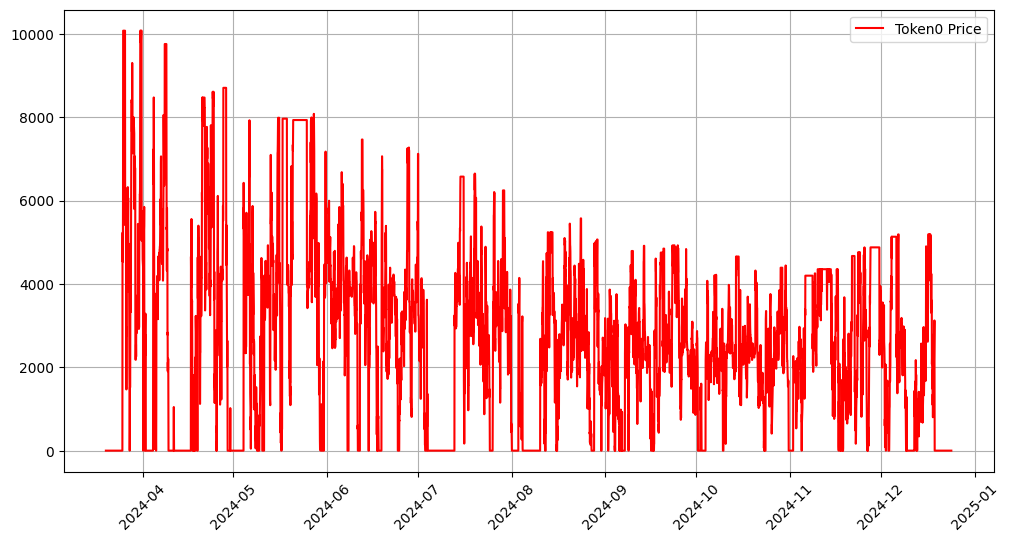

In [92]:
import numpy as np

token0_amount = df["UNISWAP_V3_token0_amount"].values
token1_amount = df["UNISWAP_V3_token1_amount"].values
price = df["UNISWAP_V3_price"].values
timestamps = df["timestamp"].values


import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, token0_amount, label='Token0 Price', color='red')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)

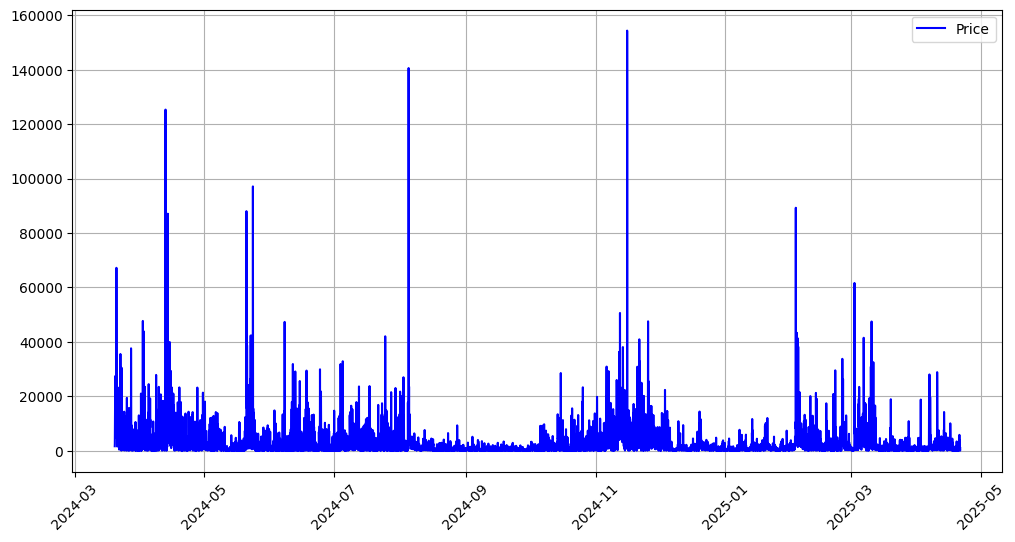

In [204]:
import numpy as np

fees_earned = [observation.states['UNISWAP_V3'].fees for observation in observations]
timestamps = [observation.timestamp for observation in observations]


import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, fees_earned, label='Price', color='blue')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)

In [203]:
train_observations[0]

Observation(timestamp=2024-03-19 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=317256101.3949567, volume=536895.7831671502, fees=1610.6873495014509, liquidity=1.4513494727019018e+18, price=3285.5963803529758, centralized_price=3293.01, open_price=3279.179804687722, close_price=3285.5963803529758, high_price=3287.09640069871, low_price=3264.396181006303)})

# Centralized price and decentralized comparison

In [4]:
observations[0]

Observation(timestamp=2025-03-09 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=300966885.4917675, volume=1913749.4990390132, fees=5741.24849711704, liquidity=5.612685138423769e+18, price=2022.9369570002336, centralized_price=2023.51, open_price=2045.213123345517, close_price=2022.9369570002336, high_price=2045.213123345517, low_price=2022.6012496692372)})

In [14]:
import numpy as np

token0_price = np.array([observation.states['UNISWAP_V3'].token0_price for observation in observations])
price = np.array([observation.states['UNISWAP_V3'].price for observation in observations])
timestamps = [observation.timestamp for observation in observations]

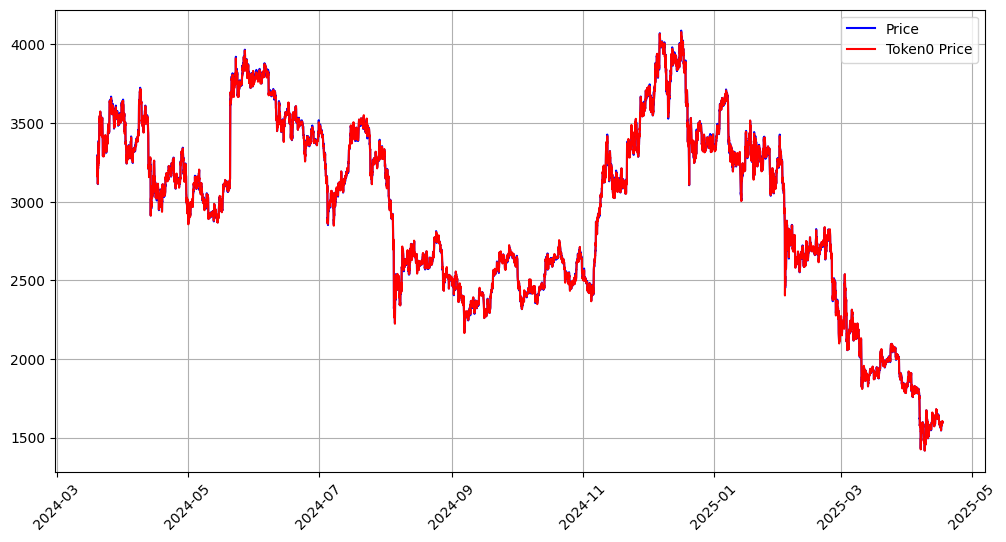

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, price, label='Price', color='blue')
ax.plot(timestamps, token0_price, label='Token0 Price', color='red')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)


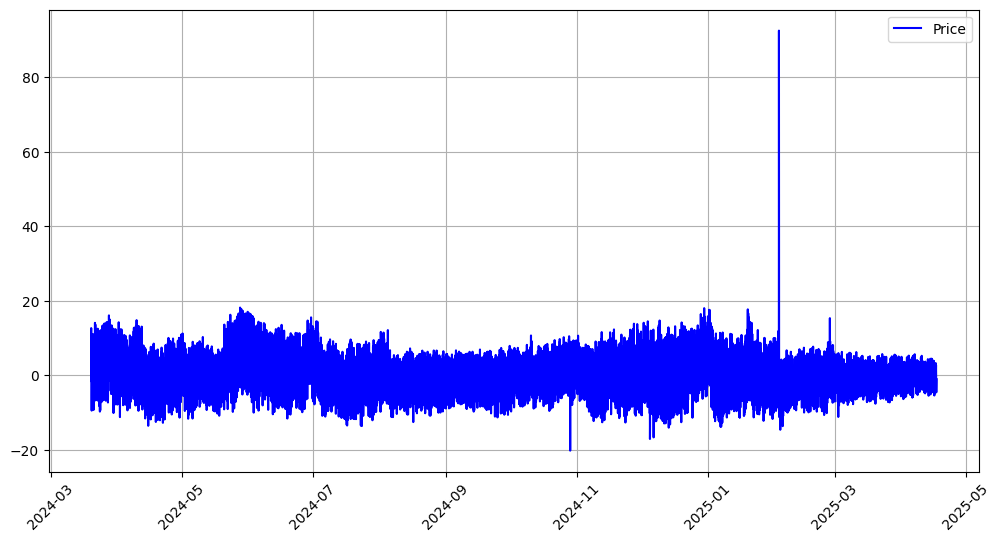

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, price - token0_price, label='Price', color='blue')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)

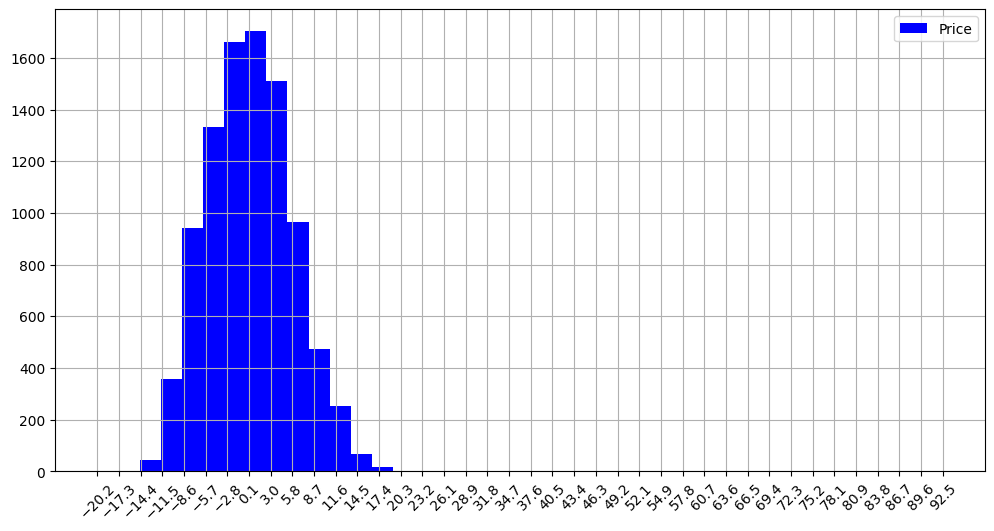

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.hist(price - token0_price, label='Price', color='blue', bins=40)
ax.legend()
ax.grid(True)

ax.set_xticks(np.linspace(min(price - token0_price), max(price - token0_price), 40))

tmp = plt.xticks(rotation=45)



### Вывод

Как будто бы нужно использовать все-таки decetralized цены для всех манипуляций, а цены из binance использовать как фичу для модели.

# Tau-reset strategy

In [73]:
from fractal.strategies.tau_reset_strategy import TauResetStrategy, TauResetParams

params: TauResetParams = TauResetParams(TAU=4, INITIAL_BALANCE=1_000_000)
TauResetStrategy.token0_decimals = token0_decimals
TauResetStrategy.token1_decimals = token1_decimals
TauResetStrategy.tick_spacing = 60
strategy: TauResetStrategy = TauResetStrategy(debug=True, params=params)


# Run the strategy
result = strategy.run(test_observations)

In [74]:
df = result.to_dataframe()
df

,timestamp,UNISWAP_V3_token0_amount_hold,UNISWAP_V3_token1_amount_hold,UNISWAP_V3_token0_amount_position,UNISWAP_V3_token1_amount_position,UNISWAP_V3_token0_amount_position_init,UNISWAP_V3_token1_amount_position_init,UNISWAP_V3_price_init,UNISWAP_V3_price_lower,UNISWAP_V3_price_upper,...,UNISWAP_V3_volume,UNISWAP_V3_fees,UNISWAP_V3_price,UNISWAP_V3_centralized_price,UNISWAP_V3_open_price,UNISWAP_V3_close_price,UNISWAP_V3_high_price,UNISWAP_V3_low_price,UNISWAP_V3_balance,net_balance
0,2025-02-05 05:00:00+00:00,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.492195e+06,7476.585807,2779.986556,2783.23,2729.600224,2779.986556,2779.986556,2718.501354,0.000000e+00,0.000000e+00
1,2025-02-05 06:00:00+00:00,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.659456e+06,4978.369042,2747.455262,2743.70,2779.380301,2747.455262,2779.380301,2747.455262,1.000000e+06,1.000000e+06
2,2025-02-05 07:00:00+00:00,0.0,0.0,6.486110e+05,127.634125,499375.000000,181.759102,2747.455262,2682.304529,2814.188447,...,8.215657e+05,2464.697126,2767.076994,2758.17,2745.775644,2767.076994,2767.077204,2745.361295,1.002863e+06,1.002863e+06
3,2025-02-05 08:00:00+00:00,0.0,0.0,7.038252e+05,107.706331,499375.000000,181.759102,2747.455262,2682.304529,2814.188447,...,6.058284e+05,1817.485240,2774.354318,2771.95,2766.164197,2774.354318,2774.354318,2764.253632,1.004333e+06,1.004333e+06
4,2025-02-05 09:00:00+00:00,0.0,0.0,5.705239e+05,155.906739,499375.000000,181.759102,2747.455262,2682.304529,2814.188447,...,1.274744e+06,3824.232949,2756.801299,2757.20,2774.353969,2756.801299,2784.116303,2756.801165,1.004306e+06,1.004306e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1901,2025-04-25 10:00:00+00:00,0.0,0.0,7.249571e+05,411.135847,727482.495123,409.713495,1775.588319,1733.483582,1818.715741,...,7.121370e+05,2136.410938,1775.441281,1770.76,1787.867771,1775.441281,1787.867771,1775.441281,1.460723e+06,1.460723e+06
1902,2025-04-25 11:00:00+00:00,0.0,0.0,9.002645e+05,312.678643,727482.495123,409.713495,1775.588319,1733.483582,1818.715741,...,5.067058e+05,1520.117343,1785.662727,1789.47,1775.442393,1785.662727,1785.662727,1775.442393,1.465942e+06,1.465942e+06
1903,2025-04-25 12:00:00+00:00,0.0,0.0,7.567874e+05,393.217100,727482.495123,409.713495,1775.588319,1733.483582,1818.715741,...,1.644056e+06,4932.167687,1777.294992,1772.00,1786.113741,1777.294992,1798.134157,1777.294992,1.467921e+06,1.467921e+06
1904,2025-04-25 13:00:00+00:00,0.0,0.0,6.633982e+05,445.843299,727482.495123,409.713495,1775.588319,1733.483582,1818.715741,...,7.907938e+05,2372.381398,1771.859001,1768.11,1777.294992,1771.859001,1777.296136,1766.656143,1.465743e+06,1.465743e+06


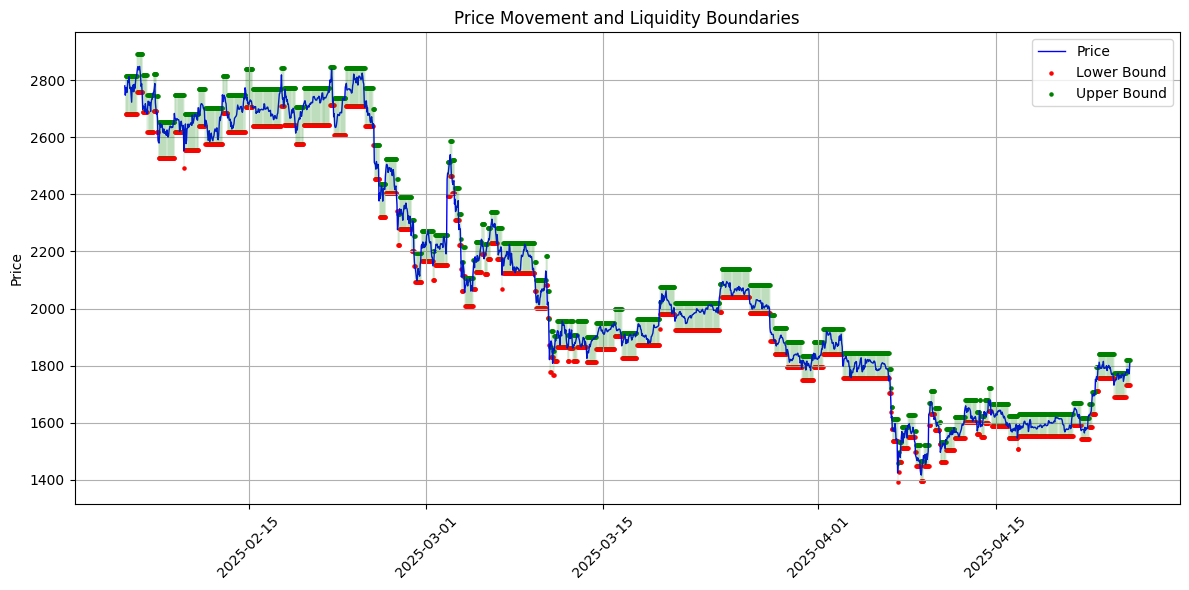

In [75]:
visualize_results(result)

In [171]:
df["UNISWAP_V3_earned_fees"].unique().sum()

np.float64(23.105988011868217)

In [14]:
result.get_default_metrics()

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  accumulated_return: float = data['net_balance'].iloc[-1] / data['net_balance'].iloc[0] - 1
/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:80: RuntimeWarning: invalid value encountered in divide
  drawdowns = net_balance / cumulative_max - 1


StrategyMetrics(accumulated_return=np.float64(inf), apy=np.float64(inf), sharpe=np.float64(nan), max_drawdown=np.float64(nan))

# Test functions

In [241]:
def get_desired_token0_amount(
    deposit_amount: float, price_current: float, price_lower: float, price_upper: float
) -> float:
    # provide liquidity by the token1 amount
    liquidity = deposit_amount / (1 / (price_current**0.5) - 1 / (price_upper**0.5))
    token0_amount = liquidity * (price_current**0.5 - price_lower**0.5)
    return token0_amount

In [243]:
deposit_amount = 1000
price_current = 1583.91
price_lower = 1281.8311
price_upper = 1891.3108
token0_amount = get_desired_token0_amount(deposit_amount / 2 / price_current, price_current, price_lower, price_upper)
ratio = token0_amount / (deposit_amount / 2 / price_current)
deposit_amount / (ratio + price_current)


0.28921188937478326

In [212]:
import math


def get_token0_amount_from_token1(
    token1_amount: float,   # Количество USDC (token1)
    price_current: float,   # Текущая цена ETH
    price_lower: float,     # Нижняя граница
    price_upper: float,     # Верхняя граница
) -> float:
    sqrt_current = math.sqrt(price_current)
    sqrt_lower = math.sqrt(price_lower)
    sqrt_upper = math.sqrt(price_upper)

    L = token1_amount / (sqrt_upper - sqrt_current)
    token0_amount = L * (sqrt_current - sqrt_lower)
    return token0_amount

In [228]:
import math

import math

def calculate_eth_from_usdc_fixed(
    usdc_amount: float,      # Количество USDC (token0)
    current_price: float,    # Текущая цена ETH в USDC (например, 1281.8311)
    price_lower: float,      # Нижняя граница (например, 1000)
    price_upper: float,      # Верхняя граница (например, 1500)
) -> float:
    """
    Рассчитывает, сколько ETH (token1) нужно внести при депозите USDC (token0)
    с учётом инвертирования цен в Uniswap v3.
    """
    # Инвертируем цены, так как USDC — token0, а ETH — token1
    inv_price_current = 1 / current_price
    inv_price_lower = 1 / price_upper  # Нижняя граница для ETH = 1 / Верхняя_граница_USDC
    inv_price_upper = 1 / price_lower  # Верхняя граница для ETH = 1 / Нижняя_граница_USDC

    sqrt_current = math.sqrt(inv_price_current)
    sqrt_lower = math.sqrt(inv_price_lower)
    sqrt_upper = math.sqrt(inv_price_upper)

    # Расчёт ликвидности (L) через USDC (token0)
    liquidity = usdc_amount / (sqrt_upper - sqrt_current)

    # Расчёт количества ETH (token1)
    eth_amount = liquidity * (sqrt_current - sqrt_lower)

    return eth_amount


In [229]:
usdc_amount = 1000
current_price = 1576.96
price_lower = 1284.3972
price_upper = 1895.097

eth_needed = calculate_eth_from_usdc_fixed(usdc_amount, current_price, price_lower, price_upper)
print(f"Необходимое количество ETH: {eth_needed:.6f}")

Необходимое количество ETH: 812.473292


In [230]:
import math

def calculate_eth_from_usdc_fixed(
    usdc_amount: float,      # Количество USDC (token0)
    current_price: float,    # Текущая цена ETH в USDC (например, 1281.8311)
    price_lower: float,      # Нижняя граница (например, 1000)
    price_upper: float,      # Верхняя граница (например, 1500)
) -> float:
    """
    Рассчитывает, сколько ETH (token1) нужно внести при депозите USDC (token0)
    с учётом инвертирования цен в Uniswap v3.
    """
    if current_price <= price_lower:
        # Если текущая цена ниже нижней границы, весь вклад будет в USDC
        return 0.0
    
    if current_price >= price_upper:
        # Если текущая цена выше верхней границы, весь вклад будет в ETH
        return usdc_amount / current_price
    
    # Если текущая цена находится в пределах диапазона
    # Расчет ликвидности (L) для USDC (token0)
    sqrt_current = math.sqrt(current_price)
    sqrt_lower = math.sqrt(price_lower)
    sqrt_upper = math.sqrt(price_upper)
    
    # Ликвидность для USDC (token0)
    liquidity = usdc_amount / (sqrt_current - sqrt_lower)
    
    # Количество ETH (token1), которое нужно внести
    eth_amount = liquidity * (sqrt_upper - sqrt_current) / (sqrt_upper * sqrt_current)
    
    return eth_amount

In [231]:
usdc_amount = 1000
current_price = 1576.96
price_lower = 1284.3972
price_upper = 1895.097

eth_needed = calculate_eth_from_usdc_fixed(usdc_amount, current_price, price_lower, price_upper)
print(f"Необходимое количество ETH: {eth_needed:.6f}")

Необходимое количество ETH: 0.570886


In [233]:
import math

def calculate_usdc_eth_distribution(
    total_amount: float,      # Общая сумма в USD (например, 1000)
    current_price: float,     # Текущая цена ETH в USDC (например, 1281.8311)
    price_lower: float,       # Нижняя граница (например, 1000)
    price_upper: float        # Верхняя граница (например, 1500)
):
    """
    Рассчитывает, сколько USDC и ETH нужно внести при депозите $1000
    с учётом инвертирования цен в Uniswap v3.
    """
    if current_price <= price_lower:
        # Если текущая цена ниже нижней границы, весь вклад будет в USDC
        return total_amount, 0.0
    
    if current_price >= price_upper:
        # Если текущая цена выше верхней границы, весь вклад будет в ETH
        eth_amount = total_amount / current_price
        return 0.0, eth_amount
    
    # Если текущая цена находится в пределах диапазона
    sqrt_current = math.sqrt(current_price)
    sqrt_lower = math.sqrt(price_lower)
    sqrt_upper = math.sqrt(price_upper)
    
    # Ликвидность (L) для общего депозита
    liquidity = total_amount / ((sqrt_current - sqrt_lower) + (sqrt_upper - sqrt_current) / (sqrt_upper * sqrt_current))
    
    # Количество USDC
    usdc_amount = liquidity * (sqrt_current - sqrt_lower)
    
    # Количество ETH
    eth_amount = liquidity * (sqrt_upper - sqrt_current) / (sqrt_upper * sqrt_current)
    
    return usdc_amount, eth_amount

In [235]:
calculate_usdc_eth_distribution(1000 / 2, 1576.96, 1284.3972, 1895.097)

(499.7147200679502, 0.2852799320498076)

In [236]:
0.2852799320498076 * 1576.96

449.8750416452646

In [260]:
def balance(token0_amount: float, token1_amount: float, price: float) -> float:
    """
    Returns the balance of the LP entity.

    Returns:
        float: The balance of the LP entity.
    """
    return (
        token0_amount + token1_amount * price
    )


In [262]:
balance(1000, 0.493943102076729215, 1580.71)

1780.7808008837067

In [26]:
def calculate_tokens_with_fees(
    X: float,       # Исходное количество token_0
    Y: float,       # Исходное количество token_1
    X_1: float,     # Требуемое количество token_0
    Y_1: float,     # Требуемое количество token_1
    price: float,   # Цена обмена token_0 на token_1 (например, 1 ETH = 1500 USDC)
    fee: float = 0.003  # Комиссия за обмен (0.3%)
):
    """
    Рассчитывает, сколько token_0 и token_1 нужно после обмена с учетом комиссий.
    """
    # Остатки токенов
    remaining_X = X - X_1
    remaining_Y = Y - Y_1

    # Если токенов достаточно, ничего менять не нужно
    if remaining_X >= 0 and remaining_Y >= 0:
        return X_1, Y_1

    # Если недостаточно token_0 (X_1 > X), нужно обменять token_1 на token_0
    if remaining_X < 0:
        # Количество token_1, которое нужно обменять на token_0
        required_X = -remaining_X
        required_Y_to_exchange = required_X * price / (1 - fee)

        # Проверяем, достаточно ли token_1 для обмена
        if Y >= Y_1 + required_Y_to_exchange:
            Y -= required_Y_to_exchange
        else:
            raise ValueError("Недостаточно token_1 для обмена на token_0")

    # Если недостаточно token_1 (Y_1 > Y), нужно обменять token_0 на token_1
    if remaining_Y < 0:
        # Количество token_0, которое нужно обменять на token_1
        required_Y = -remaining_Y
        required_X_to_exchange = required_Y / price / (1 - fee)

        # Проверяем, достаточно ли token_0 для обмена
        if X >= X_1 + required_X_to_exchange:
            X -= required_X_to_exchange
        else:
            raise ValueError("Недостаточно token_0 для обмена на token_1")

    return X_1, Y_1

In [104]:
def _get_price_from_tick(tick: int) -> float:
    """Convert tick to price using Uniswap V3 formula."""
    return 1.0001 ** tick

def _get_tick_from_price(price: float) -> int:
    """Convert price to tick using Uniswap V3 formula."""
    return int(np.log(price) / np.log(1.0001))

tick_spacing = 10
price = 1718.196
tick = _get_tick_from_price(price)
print(tick)
print(f"tick % {tick_spacing} = {tick % tick_spacing}")

next_tick = tick + tick_spacing
print(next_tick)
price = _get_price_from_tick(next_tick)
print(price)




74494
tick % 10 = 4
74504
1719.9104505733287


In [108]:
from fractal.core.entities.models.uniswap_v3_fees import get_liquidity_delta

current_price = 1757.59
lower_price = 1687.5467
upper_price = 1831.7499
amount0 = 1000
amount1 = 0.511317806703978427

liquidity_delta = get_liquidity_delta(
    P=current_price,
    lower_price=lower_price,
    upper_price=upper_price,
    amount0=amount0,
    amount1=amount1,
    token0_decimal=token0_decimals,
    token1_decimal=token1_decimals,
)
liquidity_delta

605926717470.4684

In [107]:
import math

q96 = 2**96
def price_to_sqrtp(p):
    return int(math.sqrt(p) * q96)

sqrtp_low = price_to_sqrtp(lower_price)
sqrtp_cur = price_to_sqrtp(current_price)
sqrtp_upp = price_to_sqrtp(upper_price)

def liquidity0(amount, pa, pb):
    if pa > pb:
        pa, pb = pb, pa
    return (amount * (pa * pb) / q96) / (pb - pa)

def liquidity1(amount, pa, pb):
    if pa > pb:
        pa, pb = pb, pa
    return amount * q96 / (pb - pa)

eth = 10**18
amount_eth = amount0 * eth
amount_usdc = amount1 * eth

liq0 = liquidity0(amount_eth, sqrtp_cur, sqrtp_upp)
liq1 = liquidity1(amount_usdc, sqrtp_cur, sqrtp_low)
liq = int(min(liq0, liq1))
liq

605926717470466688

In [111]:
liq - liquidity_delta

6.059261115437492e+17

In [112]:
liquidity_delta / 4176968435996541193

1.4506375299575524e-07

In [113]:
liq / 4176968435996541193

0.14506375299575486

In [ ]:
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'seaborn'

In [115]:
observation0

Observation(timestamp=2024-03-19 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=317256101.3949567, volume=536895.7831671502, fees=1610.6873495014509, liquidity=1.4513494727019018e+18, price=3285.5963803529758, centralized_price=3293.01, open_price=3279.179804687722, close_price=3285.5963803529758, high_price=3287.09640069871, low_price=3264.396181006303)})

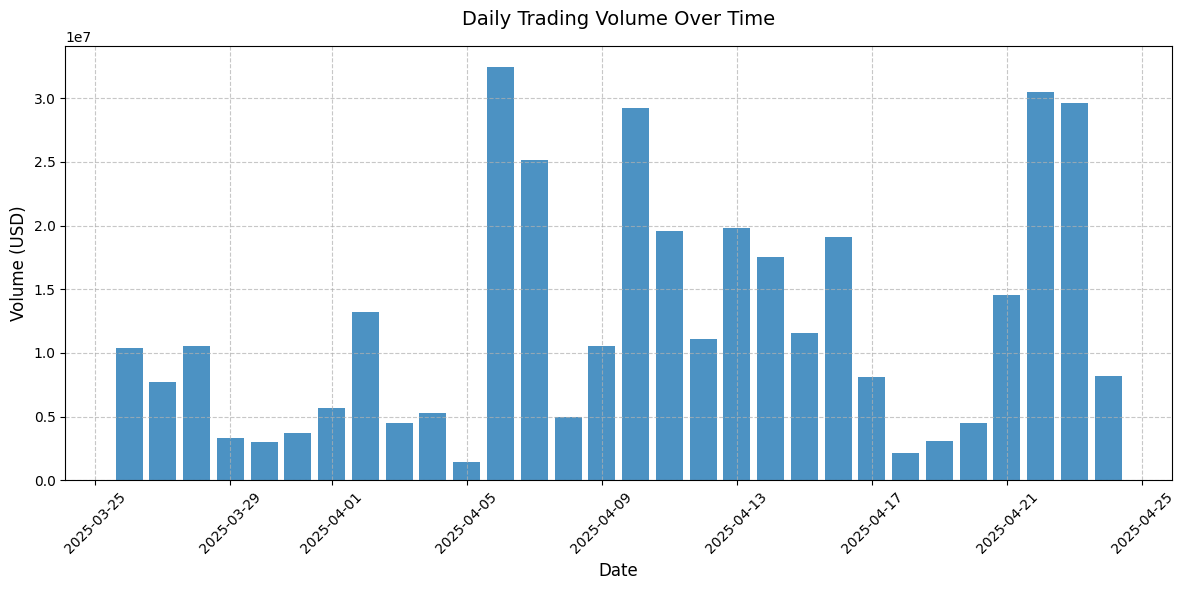

In [126]:
import pandas as pd

volumes = [obs.states["UNISWAP_V3"].volume for obs in observations]
timestamps = [obs.timestamp for obs in observations]

# Create DataFrame with hourly data
df = pd.DataFrame({
    'timestamp': timestamps,
    'volume': volumes
})

# Convert timestamp to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Resample to daily frequency and sum volumes
daily_volumes = df.resample('D', on='timestamp')['volume'].sum().tail(30)

# Create figure with larger size
fig, ax = plt.subplots(figsize=(12, 6))

# Plot data as bars
ax.bar(daily_volumes.index, daily_volumes.values, alpha=0.8, width=0.8)

# Customize plot
ax.set_title('Daily Trading Volume Over Time', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume (USD)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()


In [14]:
def get_liquidity_0(x, sa, sb):
    return x * sa * sb / (sb - sa)

def get_liquidity_1(y, sa, sb):
    return y / (sb - sa)

def get_liquidity(x, y, sp, sa, sb):
    if sp <= sa:
        liquidity = get_liquidity_0(x, sa, sb)
    elif sp < sb:
        liquidity0 = get_liquidity_0(x, sp, sb)
        liquidity1 = get_liquidity_1(y, sa, sp)
        liquidity = min(liquidity0, liquidity1)
    else:
        liquidity = get_liquidity_1(y, sa, sb)
    return liquidity


In [41]:
current_price = 1762.100355472962942566963589337255
lower_price = 1454.897522597668
upper_price = 2025.6585929082992
amount0 = 1000
amount1 = 0.409966482926903512
liquidity = 4176968435996541193
fees = 38614.31986524407919200405133893867

liquidity_delta = get_liquidity(
    x=amount0,
    y=amount1,
    sp=current_price**0.5,
    sa=lower_price**0.5,
    sb=upper_price**0.5
) * 10 ** 12
earned_fees = fees * liquidity_delta / (liquidity + liquidity_delta) 
earned_fees

0.0009884483057800702

In [42]:
Q96 = 2 ** 96


def expand_decimals(amount: float, decimals: int) -> float:
    return amount * (10 ** decimals)


def get_liquidity_for_amount0(
        sqrt_ratio_a_x96: float, sqrt_ratio_b_x96: float,
        amount0: float
) -> float:
    # amount0 * (sqrt(upper) * sqrt(lower)) / (sqrt(upper) - sqrt(lower))
    inter = sqrt_ratio_b_x96 * sqrt_ratio_a_x96 / Q96
    return amount0 * inter / (sqrt_ratio_b_x96 - sqrt_ratio_a_x96)


def get_liquidity_for_amount1(
        sqrt_ratio_a_x96: float, sqrt_ratio_b_x96: float,
        amount1: float
) -> float:
    # amount1 / (sqrt(upper) - sqrt(lower))
    return amount1 * Q96 / (sqrt_ratio_b_x96 - sqrt_ratio_a_x96)


def get_sqrt_price_x96(price: float, token0_decimal: int, token1_decimal: int) -> float:
    token0 = expand_decimals(price, token0_decimal)
    token1 = expand_decimals(1, token1_decimal)
    return ((token0 / token1)**0.5) * Q96


def get_liquidity_delta(
        P: float, lower_price: float, upper_price: float,
        amount0: float, amount1: float,
        token0_decimal: int, token1_decimal: int
) -> float:
    amt0 = expand_decimals(amount0, token1_decimal)
    amt1 = expand_decimals(amount1, token0_decimal)

    sqrt_ratio_x96 = get_sqrt_price_x96(P, token0_decimal, token1_decimal)
    sqrt_ratio_a_x96 = get_sqrt_price_x96(lower_price, token0_decimal, token1_decimal)
    sqrt_ratio_b_x96 = get_sqrt_price_x96(upper_price, token0_decimal, token1_decimal)

    if P <= lower_price:
        liquidity = get_liquidity_for_amount0(sqrt_ratio_a_x96, sqrt_ratio_b_x96, amt0)
    elif P < upper_price:
        liquidity0 = get_liquidity_for_amount0(sqrt_ratio_x96, sqrt_ratio_b_x96, amt0)
        liquidity1 = get_liquidity_for_amount1(sqrt_ratio_a_x96, sqrt_ratio_x96, amt1)
        liquidity = min(liquidity0, liquidity1)
    else:
        liquidity = get_liquidity_for_amount1(sqrt_ratio_a_x96, sqrt_ratio_b_x96, amt1)

    return liquidity


def estimate_fee(
        liquidity_delta: float, liquidity: float,
        fees: float,
) -> float:
    liquidity_percentage = liquidity_delta / (liquidity + liquidity_delta)
    return fees * liquidity_percentage

In [48]:
current_price = 1762.100355472962942566963589337255
lower_price = 1454.897522597668
upper_price = 2025.6585929082992
amount0 = 1000
amount1 = 0.409966482926903512
liquidity = 4176968435996541193
fees = 38614.31986524407919200405133893867

liquidity_delta = get_liquidity_delta(
    P=current_price,
    lower_price=lower_price,
    upper_price=upper_price,
    amount0=amount0,
    amount1=amount1,
    token0_decimal=token0_decimals,
    token1_decimal=token1_decimals,
)
earned_fees = fees * liquidity_delta / (liquidity + liquidity_delta)
earned_fees

0.0009884483057800717

In [33]:
Q96 = 2 ** 96

def expand_decimals(amount: float, decimals: int) -> float:
    return amount * (10 ** decimals)

def get_liquidity_for_amount0(
        sqrt_ratio_a_x96: float, sqrt_ratio_b_x96: float,
        amount0: float
) -> float:
    inter = sqrt_ratio_b_x96 * sqrt_ratio_a_x96 / Q96
    return amount0 * inter / (sqrt_ratio_b_x96 - sqrt_ratio_a_x96)

def get_liquidity_for_amount1(
        sqrt_ratio_a_x96: float, sqrt_ratio_b_x96: float,
        amount1: float
) -> float:
    return amount1 * Q96 / (sqrt_ratio_b_x96 - sqrt_ratio_a_x96)

def get_sqrt_price_x96(price: float, token0_decimal: int, token1_decimal: int) -> float:
    token0 = expand_decimals(price, token0_decimal)
    token1 = expand_decimals(1, token1_decimal)
    # Corrected the ratio to token1 / token0
    return ((token1 / token0) ** 0.5) * Q96

def get_liquidity_delta(
        P: float, lower_price: float, upper_price: float,
        amount0: float, amount1: float,
        token0_decimal: int, token1_decimal: int
) -> float:
    # Corrected the decimals used for expanding amounts
    amt0 = expand_decimals(amount0, token0_decimal)
    amt1 = expand_decimals(amount1, token1_decimal)

    sqrt_ratio_x96 = get_sqrt_price_x96(P, token0_decimal, token1_decimal)
    sqrt_ratio_a_x96 = get_sqrt_price_x96(lower_price, token0_decimal, token1_decimal)
    sqrt_ratio_b_x96 = get_sqrt_price_x96(upper_price, token0_decimal, token1_decimal)

    # Ensure sqrt ratios are ordered (lower < upper)
    if sqrt_ratio_a_x96 > sqrt_ratio_b_x96:
        sqrt_ratio_a_x96, sqrt_ratio_b_x96 = sqrt_ratio_b_x96, sqrt_ratio_a_x96

    if sqrt_ratio_x96 <= sqrt_ratio_a_x96:
        liquidity = get_liquidity_for_amount0(sqrt_ratio_a_x96, sqrt_ratio_b_x96, amt0)
    elif sqrt_ratio_x96 < sqrt_ratio_b_x96:
        liquidity0 = get_liquidity_for_amount0(sqrt_ratio_x96, sqrt_ratio_b_x96, amt0)
        liquidity1 = get_liquidity_for_amount1(sqrt_ratio_a_x96, sqrt_ratio_x96, amt1)
        liquidity = min(liquidity0, liquidity1)
    else:
        liquidity = get_liquidity_for_amount1(sqrt_ratio_a_x96, sqrt_ratio_b_x96, amt1)
    return liquidity

def estimate_fee(
        liquidity_delta: float, liquidity: float,
        fees: float,
) -> float:
    liquidity_percentage = liquidity_delta / (liquidity + liquidity_delta)
    return fees * liquidity_percentage


current_price = 1762.100355472962942566963589337255
lower_price = 1454.897522597668
upper_price = 2025.6585929082992
amount0 = 1000
amount1 = 0.409966482926903512
liquidity = 4176968435996541193
fees = 38614.31986524407919200405133893867

liquidity_delta = get_liquidity_delta(
    P=current_price,
    lower_price=lower_price,
    upper_price=upper_price,
    amount0=amount0,
    amount1=amount1,
    token0_decimal=token0_decimals,
    token1_decimal=token1_decimals,
)
liquidity_delta / (liquidity + liquidity_delta) * fees

2.3630541386761785